In [1]:
from pathlib import Path
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import edgepython as ep
import gseapy as gp
from XvP_utils import plotting
import re

%matplotlib inline

# (label, analysis_name, 10x_assay, parse_assay, tissue)
SAMPLES = [
    ("Exp 2a", "Analysis_3", "10x_H1",  "parse_H1"),
    ("Exp 2b", "Analysis_3", "10x_H2",  "parse_H2"),
    ("Exp 3",  "Analysis_5", "10x",      "parse"),
    ("Exp 4",  "Analysis_7", "10x",      "parse"),
]

COMPARING = {"10x": "10X", "parse": "Parse"}
TECH1, TECH2 = COMPARING.values()
FDR=0.01
PROJECT_DIR = Path("/home/mcaskey/10XvParse/")
SPECIES = "human"
INDEX_DIR = PROJECT_DIR / "Index" / SPECIES

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
combined = plotting.load_cross_comparison_data(SAMPLES, comparison=COMPARING, project_dir=PROJECT_DIR)

Loading Exp 2a...
Loading Exp 2b...
Loading Exp 3...
Loading Exp 4...

28619 genes retained across all 10 samples


TMM norm factors: [0.8629 0.887  0.8874 0.8616 1.1424 1.1402 1.2235 1.0722]
Design: 8 samples x 4 coefficients  (df.residual = 4)
Retained 25596 / 28619 genes after filterByExpr
Common dispersion (BCV): 0.3551


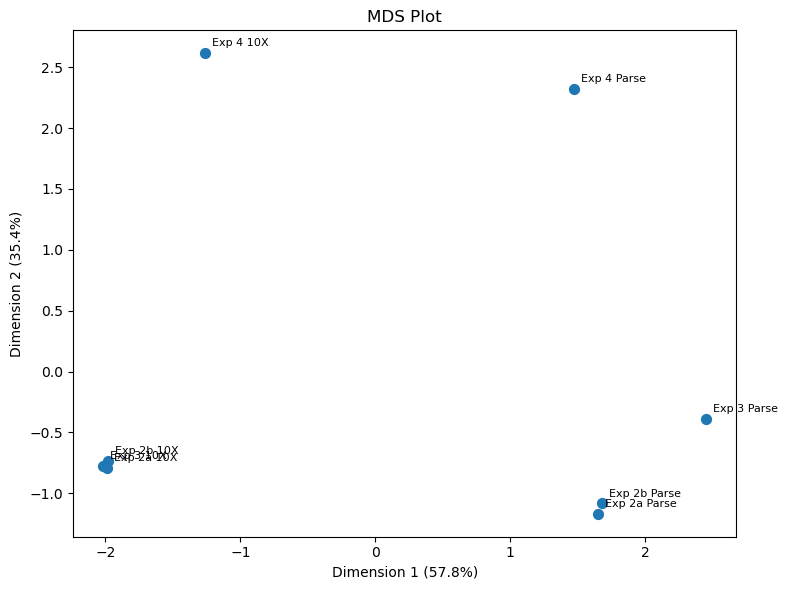

In [4]:
dge_f, fit, qlf, design, results = plotting.perform_edgepy(combined, COMPARING, SAMPLES)

labels      = [s[0] for s in SAMPLES]
col_labels  = [f"{l} {TECH1}" for l in labels] + [f"{l} {TECH2}" for l in labels]

# MDS plot
ep.plot_mds(dge_f, labels=col_labels, main="MDS Plot")

plt.show()

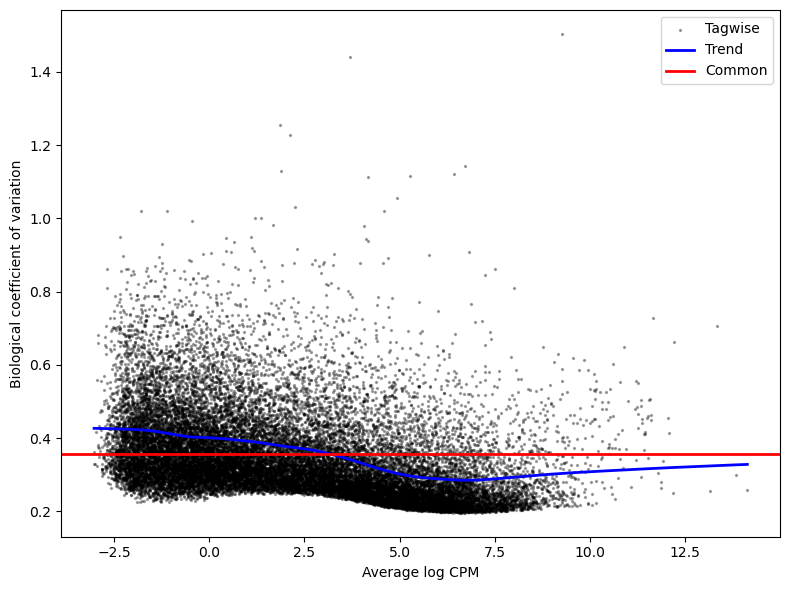

In [5]:
ep.plot_bcv(dge_f, main="BCV plot")
plt.show()

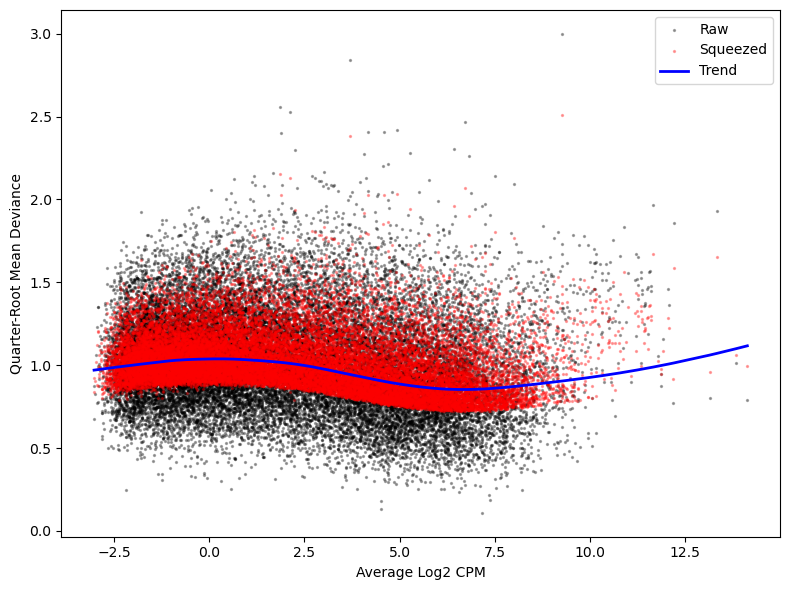

In [6]:
ep.plot_ql_disp(fit, main="QL dispersion")
plt.show()

In [7]:
# Merge gene annotations
attrs = pd.read_csv(
    PROJECT_DIR / "Notebooks/gene_info" / SPECIES / "gene_attributes.csv",
    usecols=["gene_name", "gene_length", "gc_content",
             "is_lnc", "is_pc", "is_mito", "is_ribo", "is_pseudo"],
)
results = results.merge(attrs, on="gene_name", how="left")

plotting.annotate_gene_set(
    results,
    PROJECT_DIR / "Notebooks/important_gene_sets.csv",
    "Transcription Factors",
    "is_tf",
    term ="Human",
)

# Print number of signifant genes for eachs side
n1   = ((results["FDR"] < FDR) & (results["logFC"] < 0)).sum()
n2 = ((results["FDR"] < FDR) & (results["logFC"] > 0)).sum()
print(f"FDR < {FDR}:  {n1} genes higher in {TECH1},  {n2} genes higher in {TECH2}")

annotate_gene_set: 1204/1639 "Transcription Factors" / "Human" genes matched → 'is_tf'
FDR < 0.01:  4953 genes higher in 10X,  3590 genes higher in Parse


/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: annotate_gene_set: 435 genes in "Transcription Factors" / "Human" but missing from gene_info:
  ['AC008770.3', 'AC023509.3', 'AC092835.1', 'AC138696.1', 'AHRR', 'ALX1', 'ALX3', 'ANHX', 'ARGFX', 'ARID3C', 'ARNTL', 'ARNTL2', 'ARX', 'ASCL1', 'ASCL3', 'ASCL4', 'ASCL5', 'ATOH1', 'ATOH7', 'BARHL1', 'BARHL2', 'BARX1', 'BCL6B', 'BHLHA15', 'BHLHA9', 'BHLHE22', 'BHLHE23', 'BNC1', 'BORCS8-MEF2B', 'BSX', 'C11ORF95', 'CCDC169-SOHLH2', 'CDX1', 'CDX2', 'CDX4', 'CENPBD1', 'CPXCR1', 'CREB3L1', 'CREB3L3', 'CRX', 'CSRNP3', 'CTCFL', 'DBX1', 'DBX2', 'DLX1', 'DLX2', 'DLX3', 'DLX5', 'DLX6', 'DMBX1', 'DMRT1', 'DMRT2', 'DMRT3', 'DMRTA1', 'DMRTA2', 'DMRTB1', 'DMRTC2', 'DPRX', 'DRGX', 'DUX1', 'DUX3', 'DUX4', 'DUXA', 'EBF2', 'ELF5', 'EMX1', 'EMX2', 'EN1', 'EN2', 'ESX1', 'ETV1', 'ETV4', 'EVX1', 'EVX2', 'FAM170A', 'FERD3L', 'FEV', 'FEZF1', 'FEZF2', 'FIGLA', 'FOXA1', 'FOXA2', 'FOXA3', 'FOXB2', 'FOXC2', 'FOXD1', 'FOXD3', 'FOXD4', 'FOXD4L1', 'F

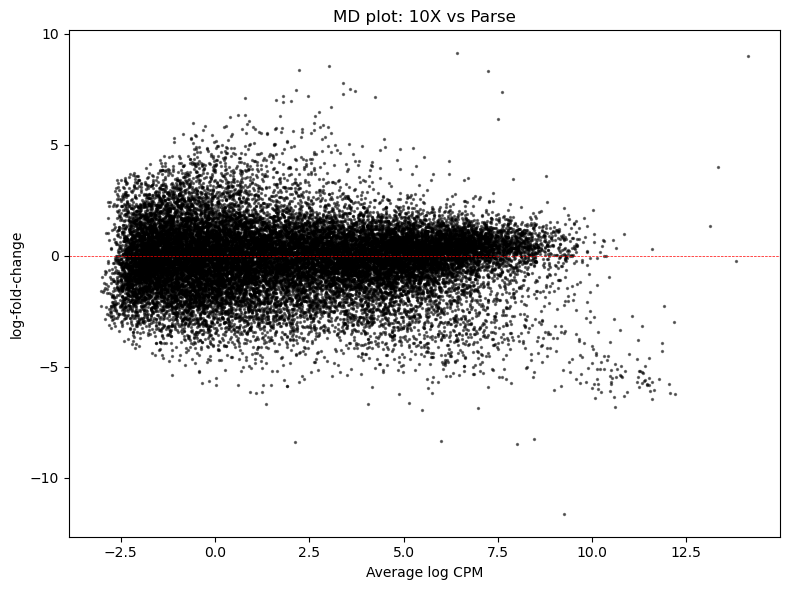

In [8]:
# MD plot
ep.plot_md(qlf, main=f"MD plot: {TECH1} vs {TECH2}")
plt.show()

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: volcano_plot: 5 genes in "PBMC Markers" but missing from results:
  ['HBB', 'IL3RA', 'LILRA4', 'PF4', 'SDC1']
  warnings.warn(


Annotated marker genes (logFC = Parse / 10X):
  PBMC Markers — 49 annotated genes labeled on plot:
     logFC > 0, higher in Parse: 7/49 (14.3%)
     logFC < 0, higher in 10X: 42/49 (85.7%)
     significant (FDR < 0.01) higher in Parse: 1/49 (2.0%)
     significant (FDR < 0.01) higher in 10X: 26/49 (53.1%)


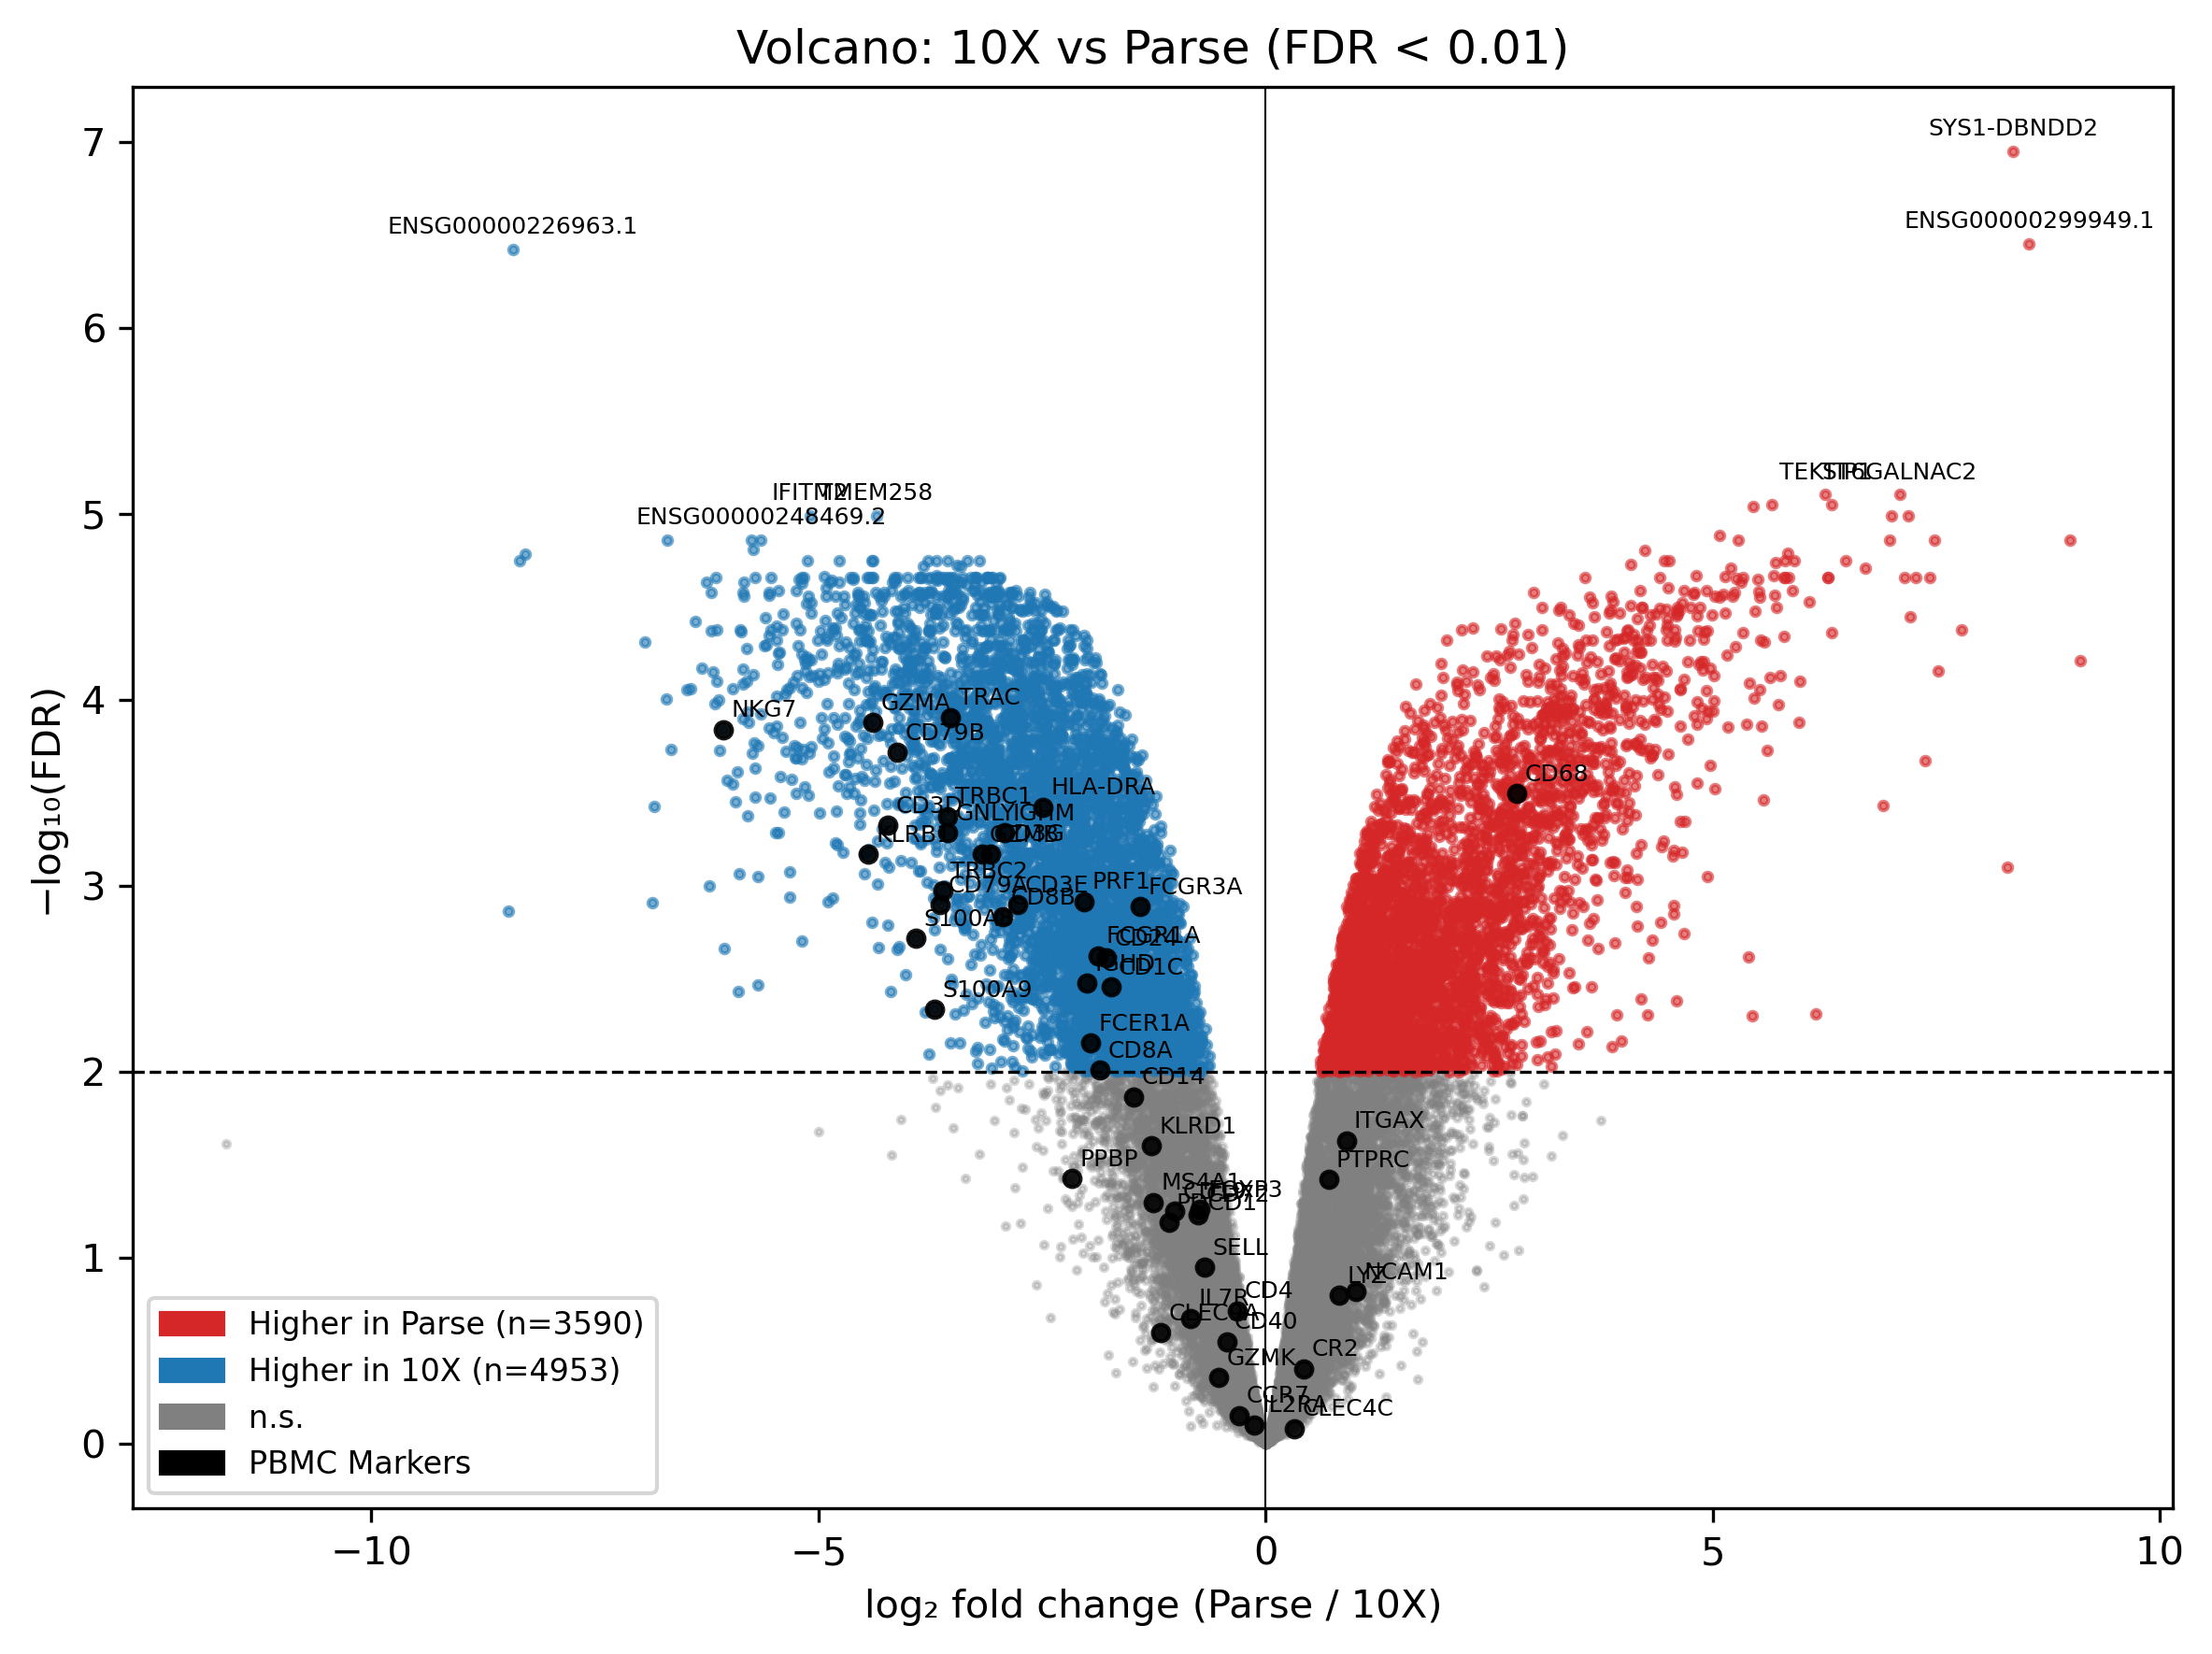

In [9]:
plotting.volcano_plot(results, 
                      COMPARING, 
                      FDR, 
                      label_num = 4,
                      marker_genes_path="/home/mcaskey/10XvParse/Notebooks/important_gene_sets.csv",
                      gene_sets=["Tissue Marker"],
                      terms=["PBMC Markers"],
                      )

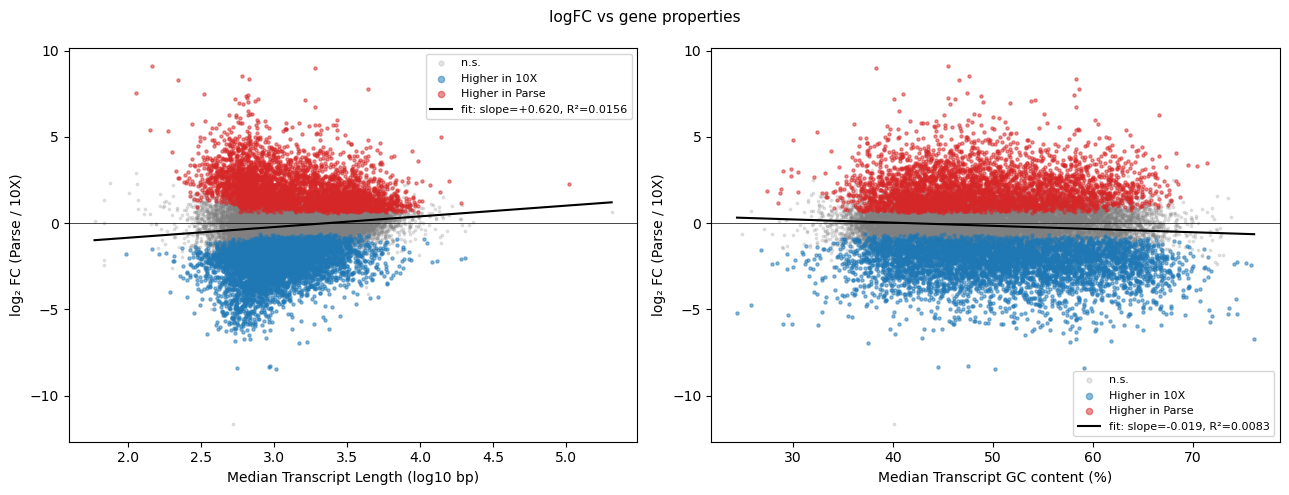

In [10]:
plotting.plot_differential_metrics(results, COMPARING, FDR)

In [11]:
gene_metrics = plotting.compute_gene_metrics(
    project_dir=PROJECT_DIR,
    index_dir=INDEX_DIR,
    species=SPECIES,
    overwrite=False,
)
results = results.merge(
    gene_metrics[["gene_name", "length_genomic", "gc_genomic",
                  "length_median_tx", "gc_median_tx",
                  "length_exon_union", "gc_exon_union"]],
    on="gene_name", how="left"
)

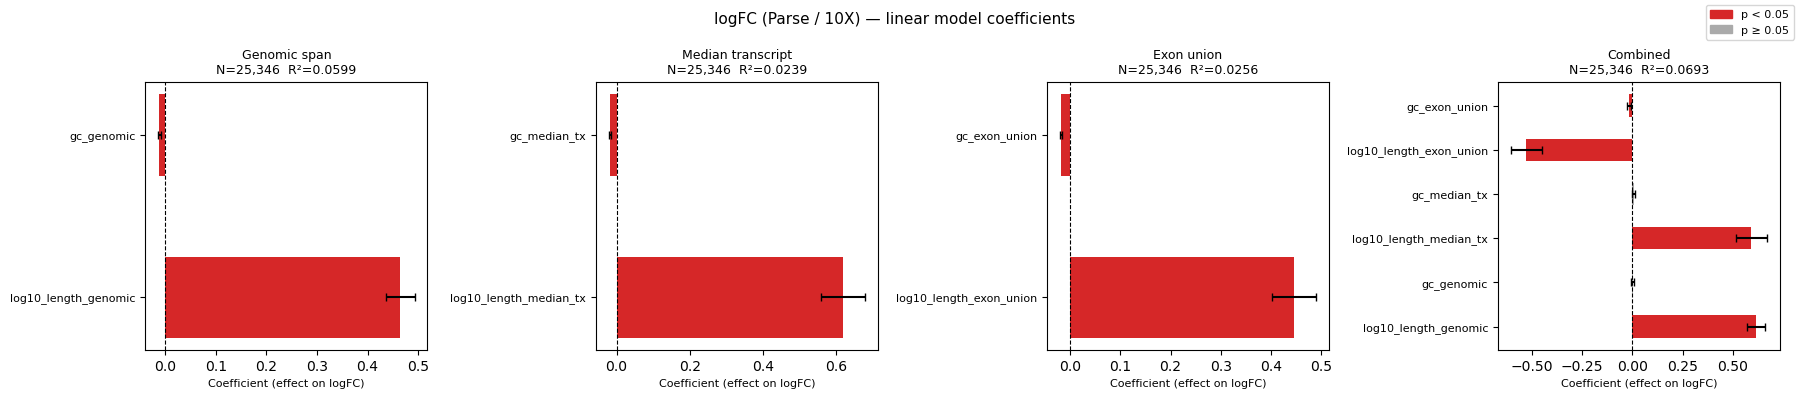

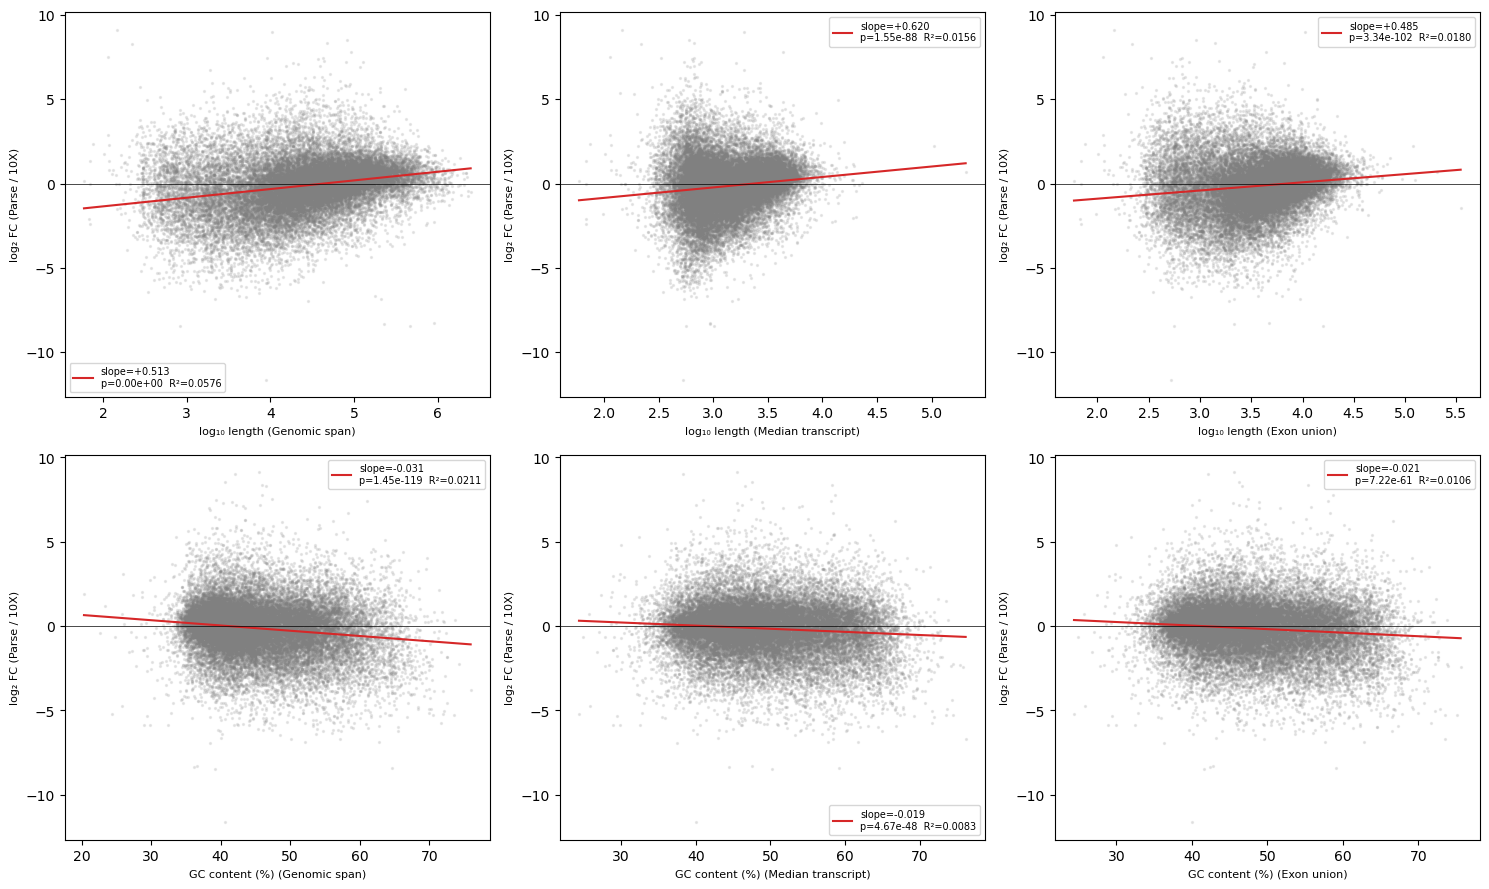

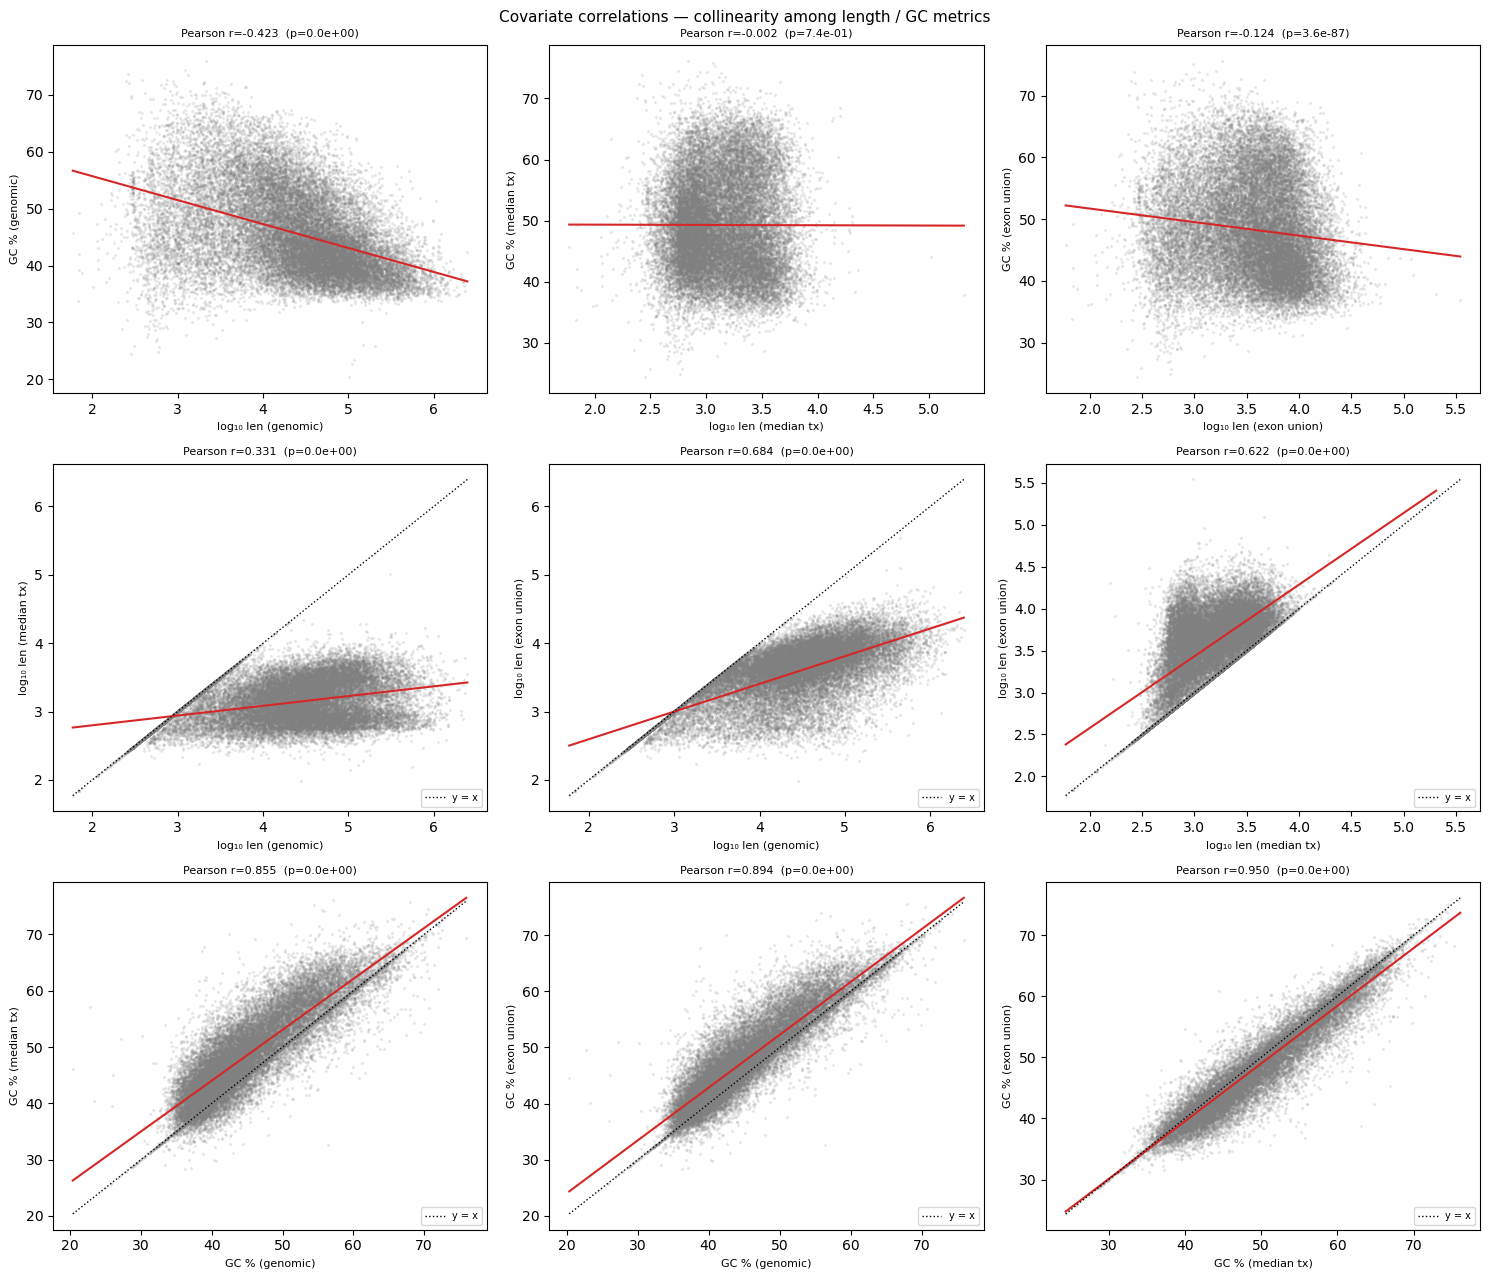


  CONFOUNDING DIAGNOSTICS  (logFC ~ length + GC, three annotation methods)
  N = 25,346

  Method             Covariate                      Uni coef      Uni p   Uni R²   Biv coef      Biv p     VIF
  ────────────────────────────────────────────────────────────────────────────────────────
  Genomic span       log10_len_genomic                0.5129   0.00e+00   0.0576     0.4648  4.70e-225    1.22
  Genomic span       gc_genomic                      -0.0312  1.45e-119   0.0211    -0.0114   2.51e-15    1.22
  Median transcript  log10_len_median_tx              0.6198   1.55e-88   0.0156     0.6188   5.30e-89    1.00
  Median transcript  gc_median_tx                    -0.0185   4.67e-48   0.0083    -0.0185   1.58e-48    1.00
  Exon union         log10_len_exon_union             0.4851  3.34e-102   0.0180     0.4458   4.44e-86    1.02
  Exon union         gc_exon_union                   -0.0210   7.22e-61   0.0106    -0.0179   1.03e-44    1.02


In [12]:
plotting.plot_logfc_lm(results, COMPARING)

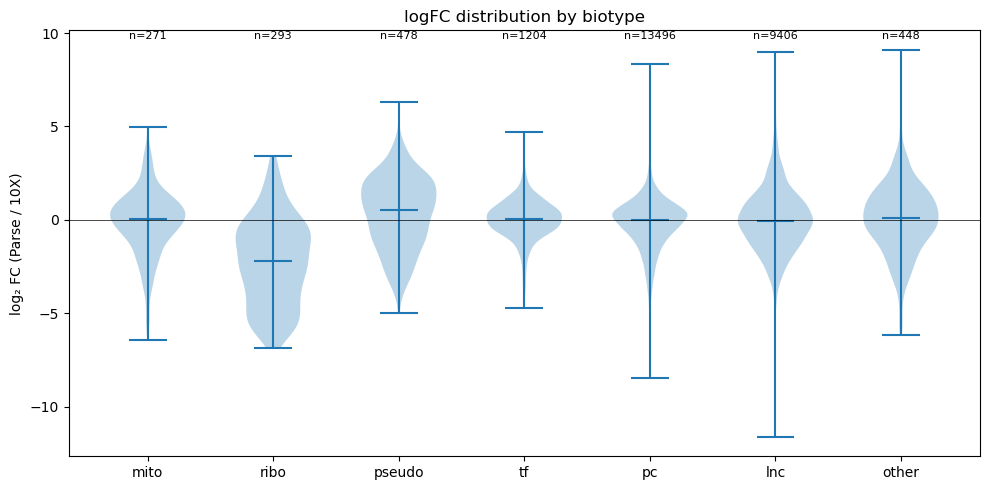

In [13]:
plotting.plot_differential_biotype(results, COMPARING)

In [14]:
sig_10x   = results.loc[(results["FDR"] < 0.01) & (results["logFC"] < 0), "gene_name"].tolist()
sig_parse = results.loc[(results["FDR"] < 0.01) & (results["logFC"] > 0), "gene_name"].tolist()

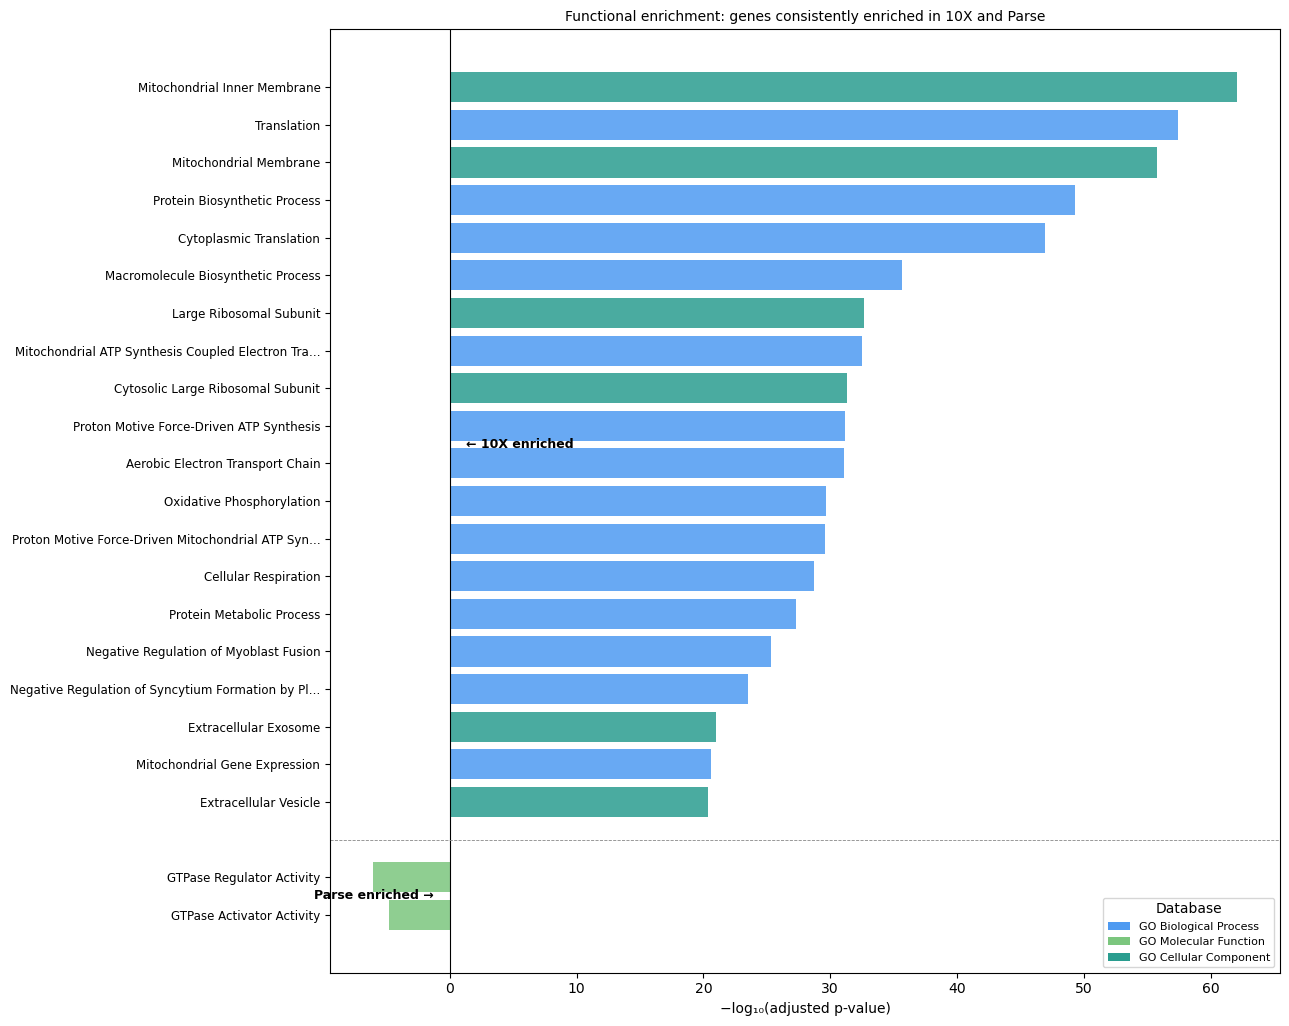

In [20]:
plotting.enrichment_analysis(combined=combined, results=results, comparing=COMPARING, fdr_thresh=FDR, max_terms=20)

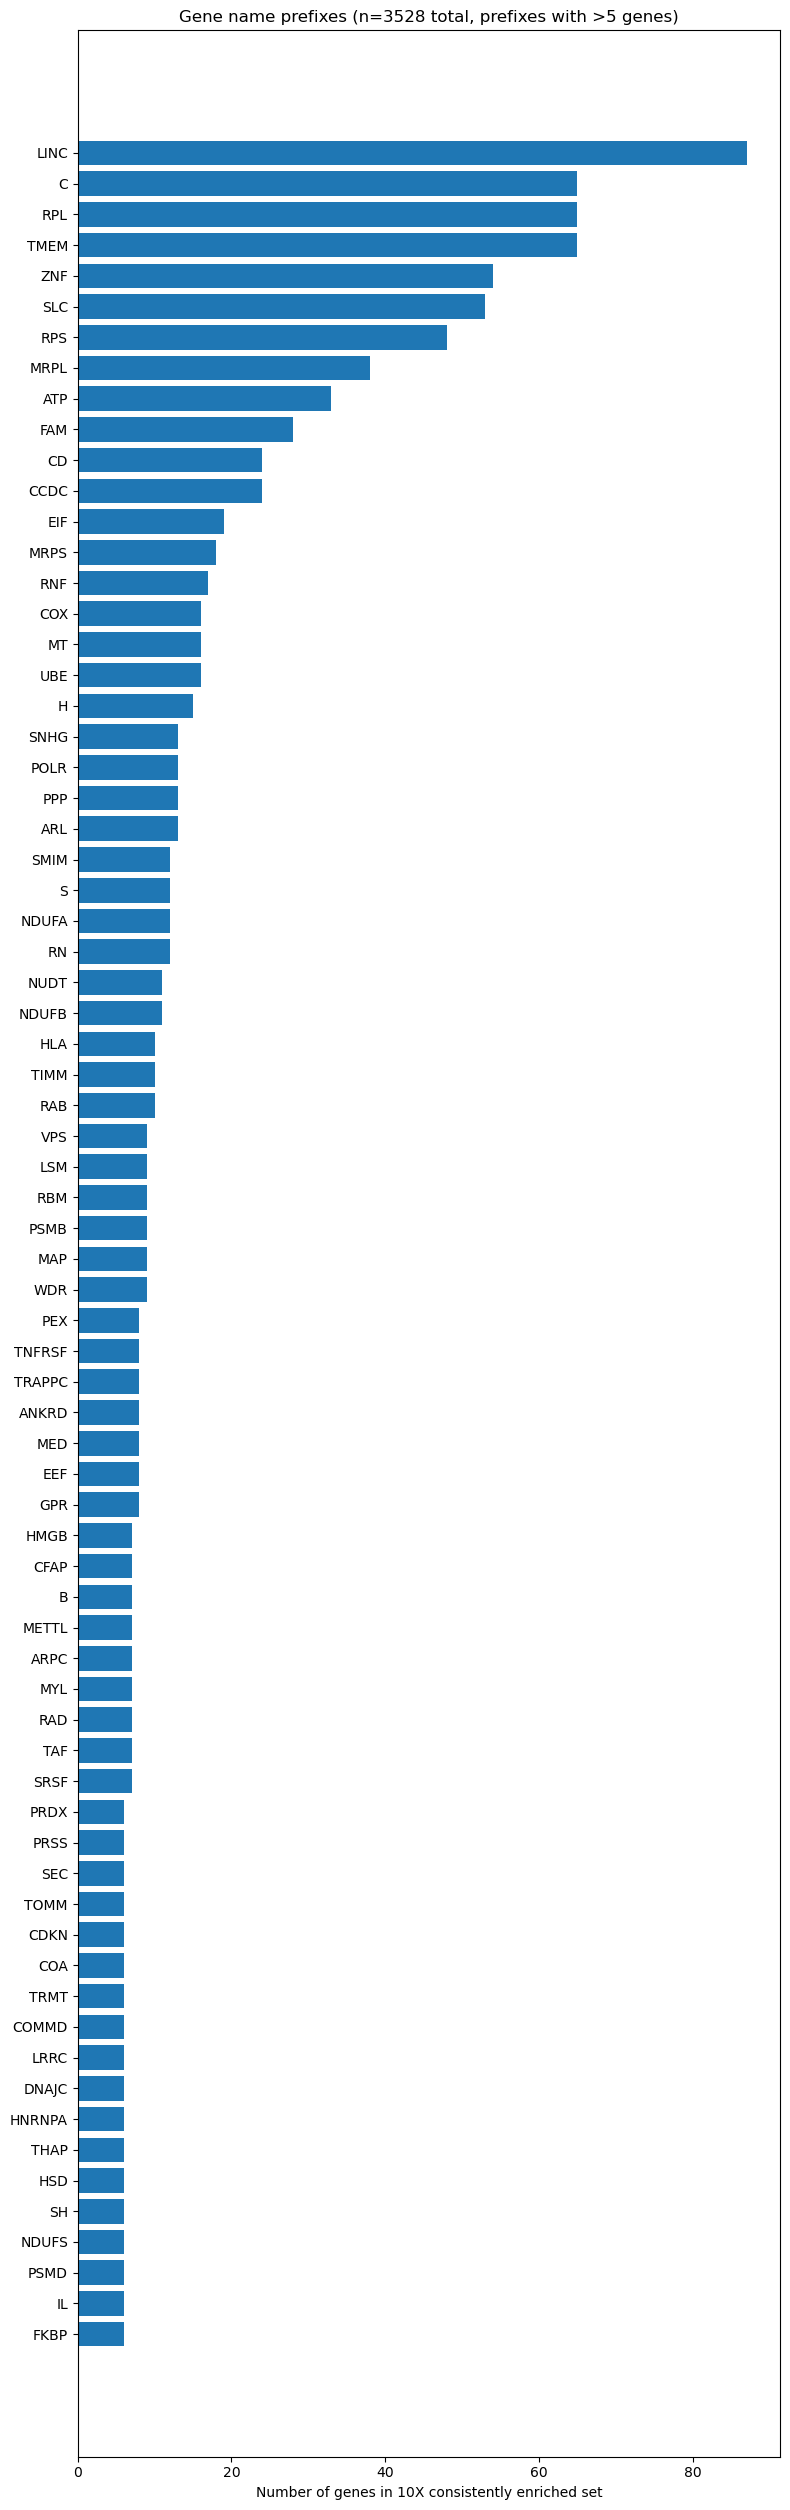

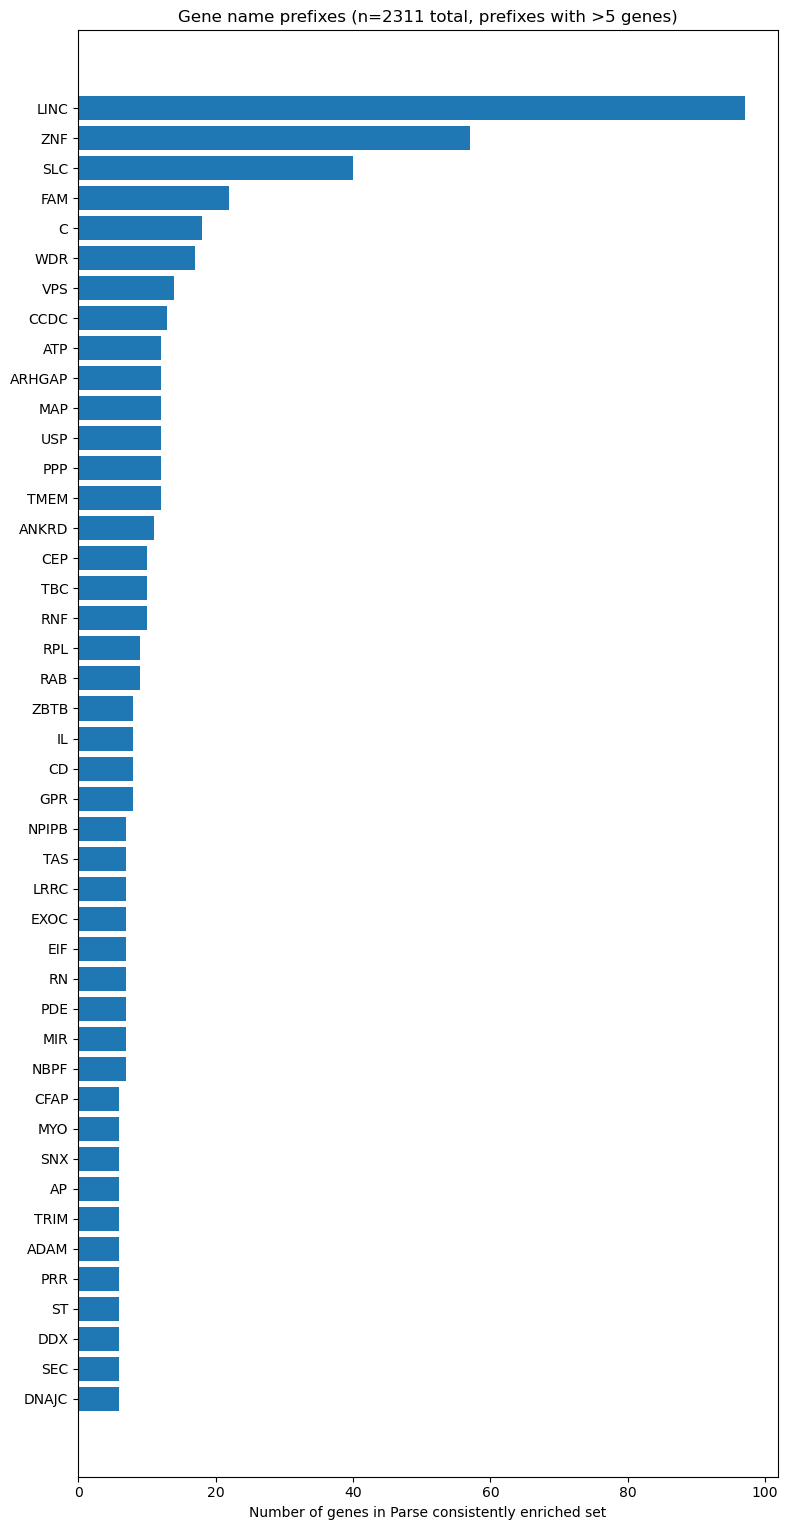

In [16]:
plotting.find_sig_prefixes(results, COMPARING, FDR)